# **Earthquake Moment Magnitude Classificaion Machine Learning Model**

This machine learning model is trained on Official Dataset from [BHUKOSH - Geological Survey of India](https://bhukosh.gsi.gov.in/Bhukosh/Public).

I have parsed and created the .csv file from .geojson file obtained from the official website.

**Importing Dependencies**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

**Importing and Pre-Processing Dataset**

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Importing Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Earthquake-Detect/earthquake.csv')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define the classification function
def classify_magnitude(mag):
    if mag < 4.5:
        return 'Light'
    elif mag < 5.5:
        return 'Moderate'
    else:
        return 'Strong'

# Apply the function to create the new classification column
df['earthquake_class'] = df['MW'].apply(classify_magnitude)

# Define the mapping to guarantee Light=0, Moderate=1, Strong=2
mapping = {'Light': 0, 'Moderate': 1, 'Strong': 2}

# Apply the mapping directly
df['earthquake_class_encoded'] = df['earthquake_class'].map(mapping)

print(df.shape)

df.head()

(35111, 7)


,LAT,LONG_,MAGMB,DEPTH_KM,MW,earthquake_class,earthquake_class_encoded
0,36.8529,70.9445,4.8,88.0,4.800,Moderate,1
1,36.8531,70.9009,3.3,88.0,3.835,Light,0
2,36.8579,71.0629,3.3,124.1,3.835,Light,0
3,36.8635,70.9343,3.5,200.0,4.005,Light,0
4,36.8677,71.0729,4.8,150.0,4.800,Moderate,1


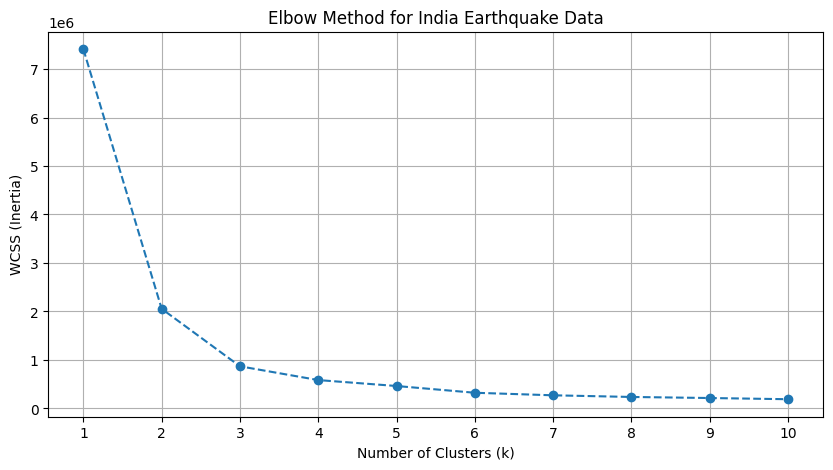

In [ ]:
spatial_data = df[['LAT', 'LONG_']]
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(spatial_data)
    wcss.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for India Earthquake Data')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
kmeans_final = KMeans(n_clusters=6, random_state=42)
df['Seismic_Zone_ID'] = kmeans_final.fit_predict(spatial_data)
df['Seismic_Zone_ID'] = df['Seismic_Zone_ID'].astype(str)

# 2. Get the Centroids
centroids = kmeans_final.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns=['LAT', 'LONG_'])

# Create the interactive map
fig = px.scatter_mapbox(
    df,
    lat="LAT",
    lon="LONG_",
    color="Seismic_Zone_ID",          # Color the points by their K-Means cluster
    hover_data=["MAGMB", "DEPTH_KM"], # What to show when you hover over a point
    color_discrete_sequence=px.colors.qualitative.G10, # A distinct color palette
    zoom=3.25,                           # Initial zoom level (3 is good for a country-level view)
    center={"lat": 22.0, "lon": 79.0},# Center the map over India
    mapbox_style="carto-positron",    # A clean, light map style (no API key needed)
    title="Seismic Zones Identified by K-Means Clustering"
)

# 4. Add the Centroids as a new layer
fig.add_trace(go.Scattermapbox(
    lat=centroid_df["LAT"],
    lon=centroid_df["LONG_"],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=10,
        color='black',
        symbol='circle'
    ),
    name="Centroids",
    hoverinfo='text',
    text=["Centroid Area" for i in range(len(centroid_df))]
))

# Adjust the layout to make it look nice in the notebook
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

# Display the interactive map
fig.show()

In [ ]:
print(centroid_df)

         LAT      LONG_
0  32.721082  80.055818
1  10.180451  93.506703
2  35.651955  71.125384
3  24.100781  94.409344
4  21.850513  72.073490
5  31.257249  89.696732


**Defining Inputs and Target for the Model.**

In [ ]:
# 1. One-Hot Encode the Seismic Zones
# This creates separate Yes/No columns for each zone (e.g., Zone_1_True, Zone_2_False)
df_model = pd.get_dummies(df, columns=['Seismic_Zone_ID'])

# 1. One-Hot Encode the Seismic Zones
# This creates separate Yes/No columns for each zone (e.g., Zone_1_True, Zone_2_False)
df_model = pd.get_dummies(df, columns=['Seismic_Zone_ID'])
print(df_model)

# 2. Define Features (X)
# We drop LAT, LONG_, and MW (since MW is what we used to create the class)
feature_cols = ['DEPTH_KM', 'MAGMB'] + [col for col in df_model.columns if 'Seismic_Zone_ID' in col]
X = df_model[feature_cols]

# 3. Define Target (y)
y = df_model['earthquake_class_encoded']

           LAT    LONG_  MAGMB  DEPTH_KM     MW earthquake_class  \
0      36.8529  70.9445    4.8      88.0  4.800         Moderate   
1      36.8531  70.9009    3.3      88.0  3.835            Light   
2      36.8579  71.0629    3.3     124.1  3.835            Light   
3      36.8635  70.9343    3.5     200.0  4.005            Light   
4      36.8677  71.0729    4.8     150.0  4.800         Moderate   
...        ...      ...    ...       ...    ...              ...   
35106   9.4890  92.8906    3.9      33.0  4.345            Light   
35107   9.8285  92.8905    3.8     100.0  4.260            Light   
35108   9.4104  92.8850    4.4      42.5  4.770         Moderate   
35109   9.1341  92.8683    4.0      33.0  4.430            Light   
35110   9.5523  92.8711    4.3      33.0  4.685         Moderate   

       earthquake_class_encoded  Seismic_Zone_ID_0  Seismic_Zone_ID_1  \
0                             1              False              False   
1                             0      

**Splliting the Dataset**

80% Training and 20% Testing Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print(X_train.shape)
print(X_test.shape)

# 1. Initialize SMOTE
# random_state ensures reproducibility
smote = SMOTE(random_state=42)

# 2. Apply SMOTE ONLY to the Training Data!
print(f"Original class distribution in training set: {Counter(y_train)}")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Balanced class distribution after SMOTE: {Counter(y_train_smote)}\n")

(28088, 8)
(7023, 8)
Original class distribution in training set: Counter({1: 14940, 0: 12200, 2: 948})
Balanced class distribution after SMOTE: Counter({0: 14940, 1: 14940, 2: 14940})



**Training the Model**

In [ ]:
# 3. Set up the Grid Search Parameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 4. Initialize the model
best_rf_smote = RandomForestClassifier(n_estimators = 50, max_depth=None, min_samples_split=10, min_samples_leaf=2, random_state=42)

**Evaluation**

Prediction on testing data

In [ ]:
'''
# 5. Initialize GridSearchCV
# We will use 'f1_macro' to ensure it evaluates both classes fairly
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='f1_macro'
)

# 6. Train the model using the NEW SMOTE data
print("Starting Grid Search on SMOTE-balanced data...")
grid_search.fit(X_train_smote, y_train_smote)

# 7. Extract the best model
best_rf_smote = grid_search.best_estimator_

print("\nGrid Search Complete!")
print(f"Best Parameters Found: {grid_search.best_params_}")
'''


best_rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=10,
                       n_estimators=50, random_state=42)

In [ ]:
# Make predictions on the REAL testing data
y_pred = best_rf_smote.predict(X_test)

# 7. Print the Classification Report
print("\nClassification Report (Test Data):")
# Target names map back to our dictionary: 0:Light, 1:Moderate, 2:Strong
print(classification_report(y_test, y_pred, target_names=['Light', 'Moderate', 'Strong']))


Classification Report (Test Data):
              precision    recall  f1-score   support

       Light       0.99      0.96      0.98      3084
    Moderate       0.97      0.99      0.98      3716
      Strong       0.97      1.00      0.98       223

    accuracy                           0.98      7023
   macro avg       0.98      0.98      0.98      7023
weighted avg       0.98      0.98      0.98      7023



**Ploting Graphs for metric evaluation and visualization**

In [ ]:
# The report is a dictionary to easily convert the per-class metrics into a DataFrame.
report_dict = classification_report(y_test, y_pred, target_names=['Light','Moderate','Strong'], output_dict=True)

# Transposes the DataFrame, making classes the rows and metrics the columns.
df_report = pd.DataFrame(report_dict).T

print(df_report)

              precision    recall  f1-score      support
Light          0.991656  0.963359  0.977303  3084.000000
Moderate       0.970240  0.991389  0.980700  3716.000000
Strong         0.969565  1.000000  0.984547   223.000000
accuracy       0.979354  0.979354  0.979354     0.979354
macro avg      0.977153  0.984916  0.980850  7023.000000
weighted avg   0.979623  0.979354  0.979330  7023.000000


[[2971  113    0]
 [  25 3684    7]
 [   0    0  223]]


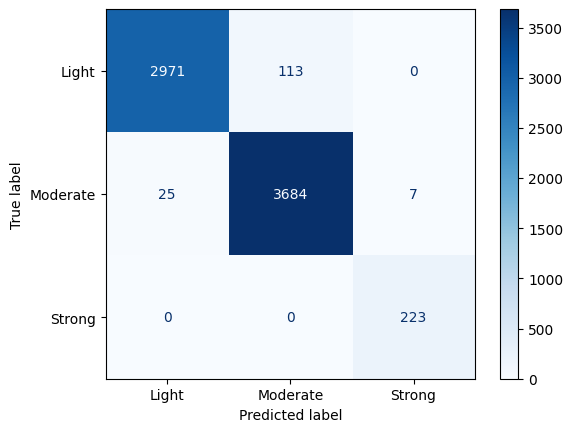

In [ ]:
# 1. Compute the raw matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 2. Visualize the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Light', 'Moderate', 'Strong'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

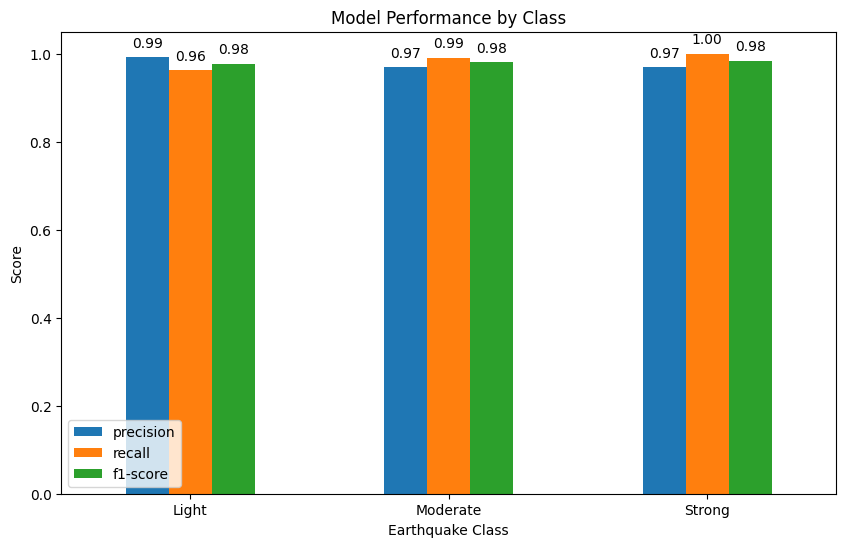

In [ ]:
# Filter the DataFrame to include only the 'Moderate' and 'Strong' classes
df_plot = df_report.loc[['Light','Moderate', 'Strong'], ['precision', 'recall', 'f1-score']]

# Create the bar plot and store the axes object
ax = df_plot.plot(kind='bar', figsize=(10, 6))

# Add a title and labels
plt.title('Model Performance by Class')
plt.xlabel('Earthquake Class')
plt.ylabel('Score')

# Add the value text on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

# Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# Add a grid for easier reading
plt.grid(axis='y', linestyle='', alpha=1)
plt.show()

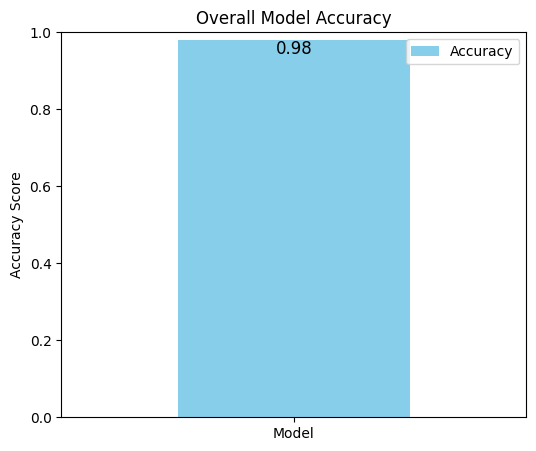

In [ ]:
# Extract the overall accuracy from the report
accuracy = report_dict['accuracy']

# Create a DataFrame for plotting the single value
df_accuracy = pd.DataFrame({'Accuracy': [accuracy]}, index=['Model'])

# Create a bar plot for accuracy
df_accuracy.plot(kind='bar', figsize=(6, 5), color='skyblue')

# Add a title and labels
plt.title('Overall Model Accuracy')
plt.xlabel('')
plt.ylabel('Accuracy Score')

# Add the accuracy value as text on the bar
plt.text(0, accuracy, f'{accuracy:.2f}', ha='center', va='top', fontsize=12)

# Set the y-axis limit for better visualization
plt.ylim(0, 1)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Add a grid for easier reading
plt.grid(axis='y', linestyle='', alpha=1)

/tmp/ipykernel_1880/490026318.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




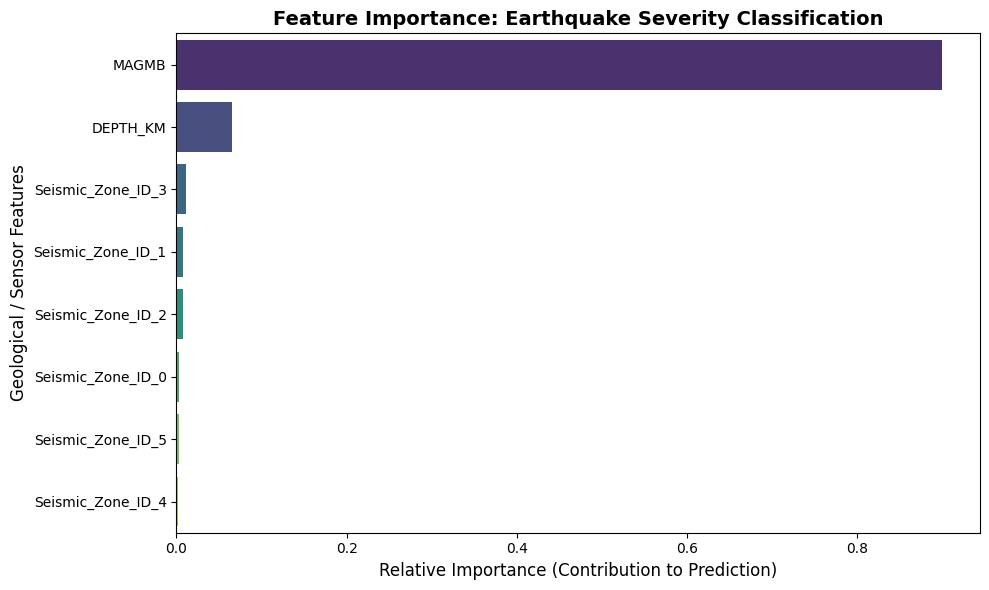

In [ ]:
# 1. Extract the feature importances from trained SMOTE model
importances = best_rf_smote.feature_importances_

# 2. Get the names of the features from original X dataframe
feature_names = X.columns

# 3. Create a DataFrame to hold the feature names and their importance scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort the DataFrame so the most important feature is at the top
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 5. Set up the matplotlib plot
plt.figure(figsize=(10, 6))

# 6. Create a horizontal bar chart using Seaborn for better styling
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

# 7. Add professional titles and labels
plt.title('Feature Importance: Earthquake Severity Classification', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Contribution to Prediction)', fontsize=12)
plt.ylabel('Geological / Sensor Features', fontsize=12)

# 8. Clean up the layout so the labels don't get cut off
plt.tight_layout()

# 10. Display the chart in Colab
plt.show()

In [ ]:
import joblib

# Export the trained SMOTE model to a binary .pkl file
joblib.dump(best_rf_smote, '/content/drive/MyDrive/Colab Notebooks/Earthquake-Detect/earthquake_classifier_model.pkl')

print("Model successfully exported as 'earthquake_classifier_model.pkl'")

Model successfully exported as 'earthquake_classifier_model.pkl'
